In [1]:
import torch
import numpy as np
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# --- Import from our custom modules ---
from dataset.generate_training_data import prepare_dataloaders, get_adjacency_matrix_and_supports
from graph_wavenet import gwnet


In [2]:

# --- Configuration ---
# This class should mirror the one in train.py for consistency
class ShapConfig:
    # Data and Model Config
    seq_len = 30
    pred_len = 10
    
    # Paths
    PROCESSED_DATA_DIR = Path("dataset/processed_data_camels")
    ADJ_MATRIX_PATH = PROCESSED_DATA_DIR / "adjacency_matrix.pkl"
    STATIC_FEATURES_PATH = PROCESSED_DATA_DIR / "static_features_array.npy"
    MODEL_WEIGHTS_PATH = "weights/best_gwnet_model.pt"
    SHAP_PLOTS_DIR = Path("plots/shap_analysis")
    
    # SHAP explainer config
    NUM_BACKGROUND_SAMPLES = 50  # Number of training samples for background dataset
    NUM_EXPLAIN_SAMPLES = 100
        # Number of test samples to explain
    
    # Training Config (needed for dataloader)
    batch_size = 32
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15

    # Device
    device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")

def get_feature_names(static_features_path):
    """
    Constructs the list of feature names for plotting.
    """
    # Dynamic features are known
    dynamic_features = [
        'Discharge', 'Precipitation', 'Solar Radiation', 'Max Temperature', 
        'Min Temperature', 'Vapor Pressure'
    ]
    
    # Load static feature names from the processed CSV header
    try:
        static_df = pd.read_csv("dataset/data/basin_characteristics.csv")
        # Use the same list of attributes as defined in the GNN paper
        static_cols_from_paper = [
            'p_mean', 'pet_mean', 'aridity', 'p_seasonality', 'frac_snow', 
            'high_prec_freq', 'high_prec_dur', 'low_prec_freq', 'low_prec_dur', 
            'elev_mean', 'slope_mean', 'area_gages2', 'frac_forest', 'lai_max', 
            'lai_diff', 'gvf_max', 'gvf_diff', 'soil_depth_pelletier', 
            'soil_depth_statsgo', 'soil_porosity', 'soil_conductivity', 
            'max_water_content', 'sand_frac', 'silt_frac', 'clay_frac', 
            'geol_permeability', 'carbonate_rocks_frac'
        ]
        # Filter to ensure we only have columns that exist in the file
        static_features_names = [col for col in static_cols_from_paper if col in static_df.columns]
    except Exception as e:
        print(f"Warning: Could not load static feature names. Using generic names. Error: {e}")
        num_static = np.load(static_features_path).shape[1]
        static_features_names = [f'static_feat_{i}' for i in range(num_static)]
        
    return dynamic_features, static_features_names

# --- Define a PyTorch Module Wrapper for SHAP ---
# This class wraps the model and the necessary input permutation.
class GwnetModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super(GwnetModelWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        """
        Wrapper for the model's forward pass to handle permutation.
        Args:
            x (torch.Tensor): Input tensor of shape (N, seq_len, nodes, features)
        Returns:
            torch.Tensor: A 2D model output of shape (N, 1) for explanation.
        """
        # Permute the input tensor to match the model's expectation
        x_permuted = x.permute(0, 3, 2, 1) # (N, features, nodes, seq_len)
        output = self.model(x_permuted).squeeze(1) # (N, pred_len, nodes)
        
        # We explain the mean of the prediction for the first time step across all nodes
        mean_output = output[:, 0, :].mean(dim=1)
        
        # Ensure the output is 2D as expected by SHAP
        return mean_output.unsqueeze(1)


In [3]:
config = ShapConfig()
config.SHAP_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("--- Preparing Data Loaders ---")
train_loader, _, test_loader, adj_matrix = prepare_dataloaders(config=config)

if train_loader is None or test_loader is None:
    print("Failed to create dataloaders. Exiting.")


# --- Load Model and Data ---
print("\n--- Loading Pre-trained Model and Data ---")

# Get model parameters from a sample batch
x_sample_batch, _ = next(iter(train_loader))
num_nodes = x_sample_batch.shape[2]
num_input_features = x_sample_batch.shape[3]

# Load graph supports
_, supports = get_adjacency_matrix_and_supports(config.ADJ_MATRIX_PATH, config.device)

# Initialize model
model = gwnet(
    device=config.device,
    num_nodes=num_nodes,
    in_dim=num_input_features,
    out_dim=config.pred_len,
    supports=supports
).to(config.device)

# Load trained weights
try:
    model.load_state_dict(torch.load(config.MODEL_WEIGHTS_PATH, map_location=config.device))
    print(f"Successfully loaded model weights from {config.MODEL_WEIGHTS_PATH}")
except FileNotFoundError:
    print(f"ERROR: Model weights not found at {config.MODEL_WEIGHTS_PATH}. Please train the model first.")

model.eval()


# Create an instance of the model wrapper
wrapped_model = GwnetModelWrapper(model)


--- Preparing Data Loaders ---
Loading processed data...
  Timeseries data: (12784, 671, 6)
  Static features array: (671, 27)
  Adjacency matrix shape: (671, 671)

Configuration: Using 2 time series (discharge and rainfall).
Configuration: Using static features.
Data split into Train (8948), Val (1918), Test (1918) sets.
Fitting scalers on training data for 671 nodes and 6 features individually...
  Scaling discharge (feature 0) using StandardScaler for each node...


  Scaling rainfall/other (feature 1) for each node...
  Scaling rainfall/other (feature 2) for each node...
  Scaling rainfall/other (feature 3) for each node...
  Scaling rainfall/other (feature 4) for each node...
  Scaling rainfall/other (feature 5) for each node...
  Node-and-feature-wise scaling complete.
  Saved scalers for all time series to dataset/processed_data_camels/timeseries_node_scalers.pkl
Scaled train data: [[[-4.58894870e-01 -6.13741105e-01 -1.02836180e+00 -1.28239005e+00
   -1.12296511e+00 -1.03093845e+00]
  [-1.38611341e-01 -4.82250980e-01 -1.01534021e+00 -1.20164720e+00
   -1.11039862e+00 -1.06249507e+00]
  [ 2.14482284e-02 -5.35036434e-01 -9.74525937e-01 -1.21599808e+00
   -1.09190937e+00 -1.02135234e+00]
  ...
  [ 1.45108494e+00  1.99443281e-01 -1.69126735e+00 -8.35572269e-01
    2.91836644e-01  3.70924501e-01]
  [-3.26999664e-01 -1.30951036e-01 -1.37922266e+00 -9.04474919e-01
   -2.38463106e-01  2.37444565e-01]
  [ 1.92275976e+00  8.44104612e-02 -1.70683113e+00 

In [4]:
# --- Prepare Data for SHAP ---
print("\n--- Preparing Background and Test Sets for SHAP ---")

# Create a background dataset from the training loader
background_data = []
for x_batch, _ in train_loader:
    background_data.append(x_batch)
    if len(background_data) * config.batch_size >= config.NUM_BACKGROUND_SAMPLES:
        break
background_data = torch.cat(background_data, dim=0)[:config.NUM_BACKGROUND_SAMPLES].to(config.device)

# Create a test dataset to explain
test_data = []
for x_batch, _ in test_loader:
    test_data.append(x_batch)
    if len(test_data) * config.batch_size >= config.NUM_EXPLAIN_SAMPLES:
        break
test_data = torch.cat(test_data, dim=0)[:config.NUM_EXPLAIN_SAMPLES].to(config.device)

print(f"Background data shape: {background_data.shape}")
print(f"Test data shape: {test_data.shape}")



--- Preparing Background and Test Sets for SHAP ---
Background data shape: torch.Size([50, 30, 671, 33])
Test data shape: torch.Size([100, 30, 671, 33])


In [5]:

# --- Initialize SHAP Explainer ---
print("\n--- Initializing SHAP DeepExplainer ---")
explainer = shap.DeepExplainer(wrapped_model, background_data)

# --- Calculate SHAP values ---
print(f"\n--- Calculating SHAP values for {config.NUM_EXPLAIN_SAMPLES} test samples ---")
shap_values = explainer.shap_values(test_data, check_additivity=False)

# The output shape will be (num_samples, seq_len, num_nodes, num_features)
print(f"SHAP values calculated with shape: {shap_values.shape}")

# --- Visualize SHAP Values ---
print("\n--- Generating SHAP Visualization Plots ---")

# Reshape the SHAP values and test_data for plotting
shap_values_reshaped = shap_values.reshape(-1, num_input_features)
test_data_reshaped = test_data.cpu().numpy().reshape(-1, num_input_features)

dynamic_feature_names, static_feature_names = get_feature_names(config.STATIC_FEATURES_PATH)
all_feature_names = dynamic_feature_names + static_feature_names



--- Initializing SHAP DeepExplainer ---



--- Calculating SHAP values for 100 test samples ---


/aul/homes/nhoan009/discharge_forecast/.venv/lib64/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: nconv
  warnings.warn(f"unrecognized nn.Module: {module_type}")


SHAP values calculated with shape: (100, 30, 671, 33, 1)

--- Generating SHAP Visualization Plots ---


SHAP summary dot plot saved to: plots/shap_analysis/feature_importance_summary_dot.png


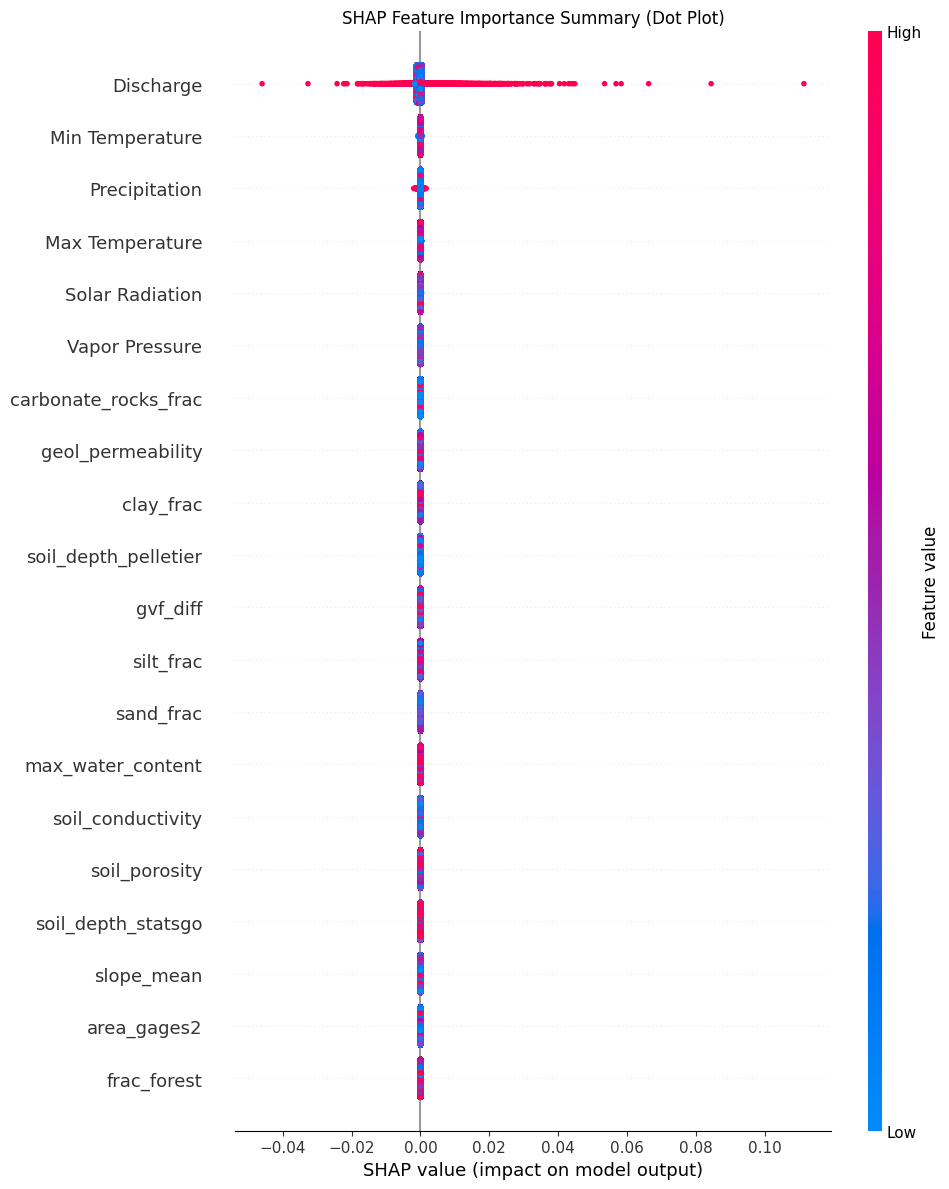

In [6]:

# Plot 1: Standard Summary Plot (dot version)
shap.summary_plot(
    shap_values_reshaped,
    test_data_reshaped,
    feature_names=all_feature_names,
    show=False,
    plot_type='dot'
)
plt.gcf().set_size_inches(10, 12)
plt.title("SHAP Feature Importance Summary (Dot Plot)")
plt.tight_layout()
save_path = config.SHAP_PLOTS_DIR / "feature_importance_summary_dot.png"
plt.savefig(save_path, dpi=150)
print(f"SHAP summary dot plot saved to: {save_path}")
plt.show()
plt.close()


SHAP summary bar plot saved to: plots/shap_analysis/feature_importance_summary_bar.png


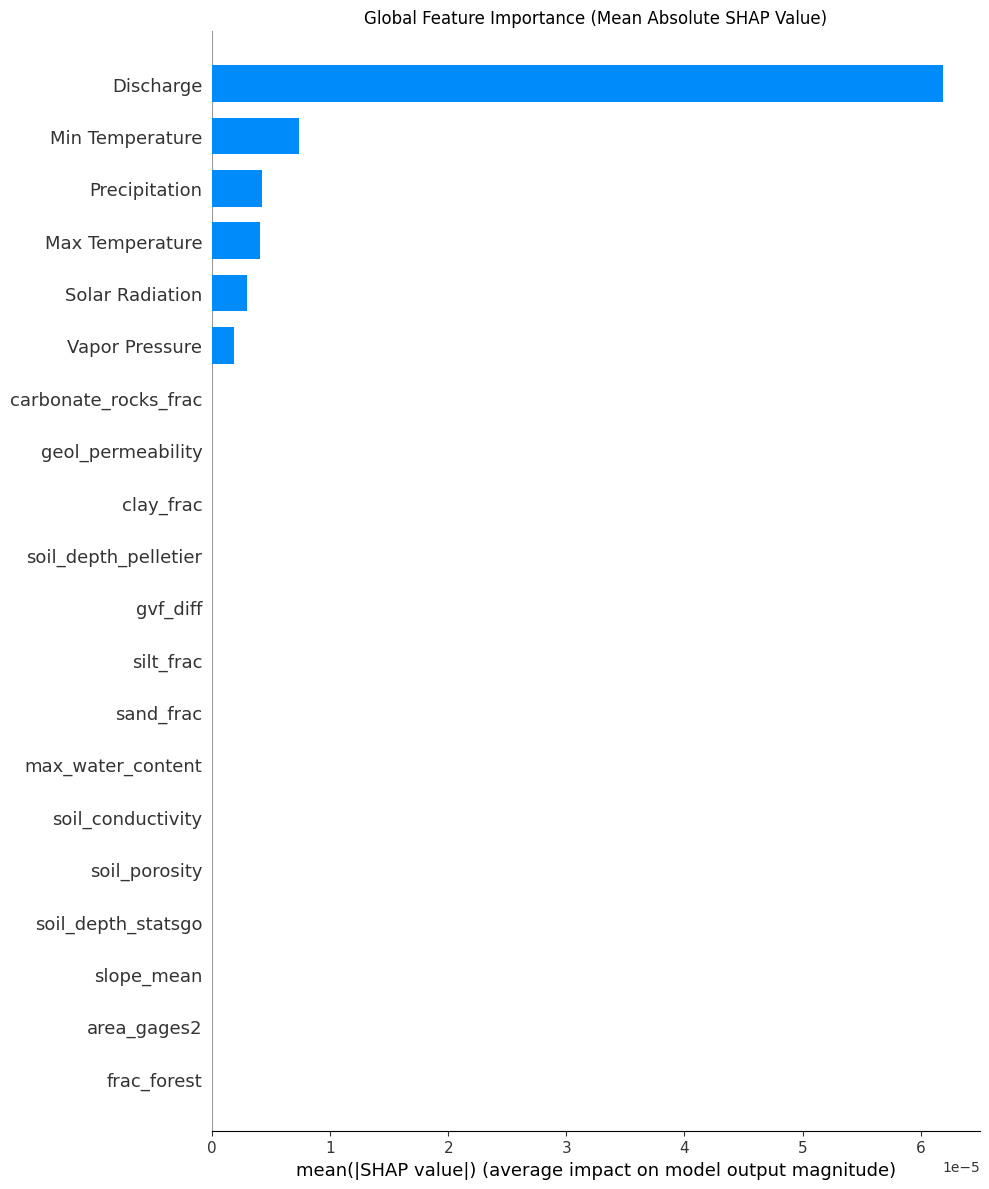

In [7]:

# Plot 2: Bar Chart Summary Plot
shap.summary_plot(
    shap_values_reshaped,
    test_data_reshaped,
    feature_names=all_feature_names,
    show=False,
    plot_type='bar'
)
plt.gcf().set_size_inches(10, 12)
plt.title("Global Feature Importance (Mean Absolute SHAP Value)")
plt.tight_layout()
save_path = config.SHAP_PLOTS_DIR / "feature_importance_summary_bar.png"
plt.savefig(save_path, dpi=150)
print(f"SHAP summary bar plot saved to: {save_path}")
plt.show()
plt.close()


Temporal importance plot saved to: plots/shap_analysis/temporal_feature_importance.png


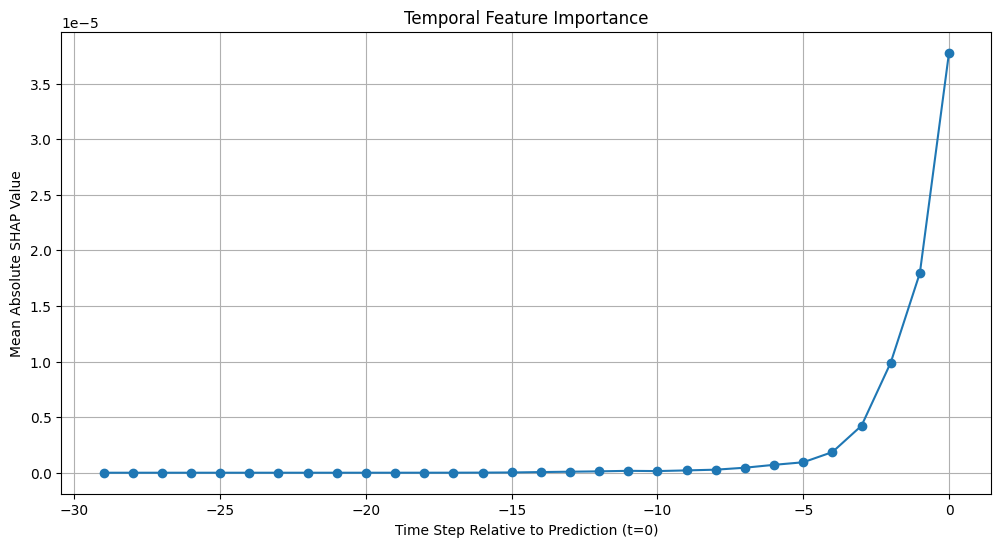

In [8]:

# Plot 3: Temporal Importance Plot
# Average the absolute SHAP values across samples, nodes, and features for each time step
# Shape of shap_values: (num_samples, seq_len, num_nodes, num_features)
temporal_importance = np.abs(shap_values).mean(axis=(0, 2, 3))
plt.figure(figsize=(12, 6))
time_steps = np.arange(-config.seq_len + 1, 1)
plt.plot(time_steps, temporal_importance, marker='o', linestyle='-')
plt.xlabel("Time Step Relative to Prediction (t=0)")
plt.ylabel("Mean Absolute SHAP Value")
plt.title("Temporal Feature Importance")
plt.grid(True)
save_path = config.SHAP_PLOTS_DIR / "temporal_feature_importance.png"
plt.savefig(save_path, dpi=150)
print(f"Temporal importance plot saved to: {save_path}")
plt.show()
plt.close()


Dynamic vs. static importance plot saved to: plots/shap_analysis/dynamic_vs_static_importance.png


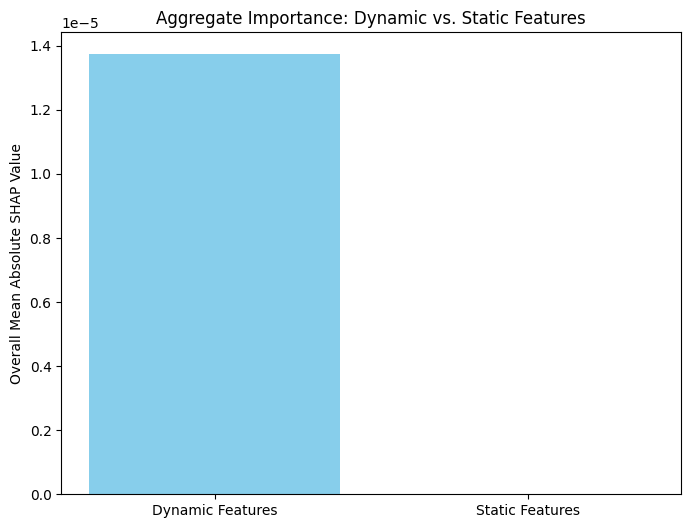


--- SHAP Analysis Complete ---


In [9]:

# Plot 4: Dynamic vs Static Feature Importance
num_dynamic = len(dynamic_feature_names)
mean_abs_shap_dynamic = np.abs(shap_values_reshaped[:, :num_dynamic]).mean()
mean_abs_shap_static = np.abs(shap_values_reshaped[:, num_dynamic:]).mean()

plt.figure(figsize=(8, 6))
plt.bar(['Dynamic Features', 'Static Features'], [mean_abs_shap_dynamic, mean_abs_shap_static], color=['skyblue', 'salmon'])
plt.ylabel("Overall Mean Absolute SHAP Value")
plt.title("Aggregate Importance: Dynamic vs. Static Features")
save_path = config.SHAP_PLOTS_DIR / "dynamic_vs_static_importance.png"
plt.savefig(save_path, dpi=150)
print(f"Dynamic vs. static importance plot saved to: {save_path}")
plt.show()
plt.close()

print("\n--- SHAP Analysis Complete ---")


In [10]:

# Plot 3: Bar Chart Discharge Plot
shap.summary_plot(
    shap_values_reshaped[:, 0],  # Only plot the first feature (Discharge)
    test_data_reshaped[:, 0].reshape(-1, 1),  # Reshape to match
    feature_names=['Discharge'],
    show=False,
    plot_type='bar'
)
plt.gcf().set_size_inches(10, 6)
plt.title("Discharge Feature Importance (Bar Plot)")
plt.tight_layout()
save_path = config.SHAP_PLOTS_DIR / "discharge_feature_importance_bar.png"
plt.savefig(save_path, dpi=150)
print(f"Discharge feature importance bar plot saved to: {save_path}")
plt.show()
plt.close()


AssertionError: Summary plots need a matrix of shap_values, not a vector.